To answer Q1 and Q2, I used the following four datasets.

### Dataset 01

The dataset was generated from two classes, where observations from class A and class B have different means.

In [1]:
import numpy as np

# initialize parameters
n, muA, muB, sd0 = 500, 0, 20, 10 
# initialize labels
y1 = np.random.choice(["A", "B"], size=n, replace=True)
meanX = np.where(y1 == "A", muA, muB)
# generate the data
x1 = np.random.normal(loc=meanX, scale=sd0)

### Dataset 02 

The dataset was generated from two multivariate normal distributions with different class means and a common covariance matrix.

In [2]:
# sample size
n1, n2 = 500, 500

# means for two classes
mu1 = [10, 10]
mu2 = [30, 30]

# covariance
s = [[60, 0],
     [0, 60]]

# generate the data
f1 = np.random.multivariate_normal(mean=mu1, cov=s, size=n1)
f2 = np.random.multivariate_normal(mean=mu2, cov=s, size=n2)

x2 = np.vstack((f1, f2))
y2 = np.array([1]*n1 + [2]*n2)

### Dataset 03

The dataset was generated from a single multivariate normal distribution, where class labels are determined by a noisy threshold on the first feature.

In [3]:
n = 500  # sample size
mu = [10, 10] # mean

# covariance
s = [[1, 0],
     [0, 1]]

# generate the data
x3 = np.random.multivariate_normal(mean=mu, cov=s, size=n)

# create noise
noise = np.random.normal(scale=0.25, size=n)
y3 = np.where(x3[:, 0] + noise > 10, 1, 2)

### Dataset 04

The dataset has noisy class boundaries, with labels assigned based on whether both features exceed specified thresholds after adding noise.

In [4]:
n = 500 # sample size

mu1, mu2 = 0, 0 # mean
sd1, sd2 = 5, 5 # sd
sd0 = 3

X1bound, X2bound = 0, 0

# generate x
f1 = np.random.normal(loc=mu1, scale=sd1, size=n)
f2 = np.random.normal(loc=mu2, scale=sd2, size=n)

# initialize labels
Y = np.array(["A"] * n)

# noisy boundary condition
noise1 = np.random.normal(scale=2 * sd0, size=n)
noise2 = np.random.normal(scale=sd0, size=n)

mask = ((f1 + noise1) > X1bound) & ((f2 + noise2) > X2bound)
Y[mask] = "B"

x4 = np.vstack((f1, f2)).T
y4 = Y

In [5]:
# function to plot the confusion matrix
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split

def plotConfusionMatrix(model_name, y_test, y_pred):
    cm = confusion_matrix(y_test, y_pred)
    # plot confusion matrix
    p = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Class 0', 'Class 1'])
    p.plot(cmap=plt.cm.Blues)
    plt.title(f"Confusion Matrix for {model_name}")
    plt.show()

# Q1 

In [6]:
import numpy as np
from sklearn.neighbors import KNeighborsClassifier

def KNNcv(train, test, cl):
    
    vec = [] # vector to store accuracy
    n = len(train)
    kvals = np.arange(1,5) # range of k values to check
    
    # loop over k values
    for k in kvals:
        
        acc = 0
        # set KNN classifier 
        knn = KNeighborsClassifier(n_neighbors=k)
        
        # perform leave-one-out cross-validation
        for i in range(n):
            # # vector of boolean ones
            idx = np.ones(n, dtype=bool)
            # select i-th row as test sample
            idx[i] = False
            
            # split into training data
            X_train, y_train = train[idx], cl[idx] 
            # split into test data
            X_test, y_test =  train[i], cl[i]
            
            # reshape from 1D to 2D
            X_test = X_test.reshape(1,-1)
            y_test = np.array([y_test])
            
            # fit KNN model
            knn.fit(X_train, y_train)
            # perform prediction
            y_pred = knn.predict(X_test)
            # count correct predictions
            if y_test == y_pred:
                acc += 1
                
        # calculate accuracy
        acc = (acc / n)
        vec.append([k, acc])
        
        
    # find the optimal k    
    vec = np.array(vec)
    idx = np.argmax(vec[:, 1])
    best_k = int(vec[idx, 0])
    
    # perform training with optimal k
    knn = KNeighborsClassifier(n_neighbors=best_k)
    knn.fit(train, cl)
    
    # perform prediction on test data
    y_pred = knn.predict(test)

    # return predictions for test data and optimal k
    return y_pred, best_k

#### Case 1: Using Dataset 01

Best k: 3

Accuracy: 0.768

Classification report

              precision    recall  f1-score   support

           A       0.82      0.74      0.78        68
           B       0.72      0.81      0.76        57

    accuracy                           0.77       125
   macro avg       0.77      0.77      0.77       125
weighted avg       0.77      0.77      0.77       125



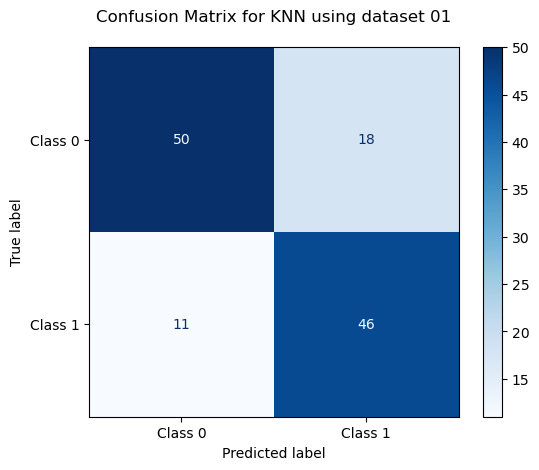

In [7]:
X_train, X_test, y_train, y_test = train_test_split(x1.reshape(-1, 1), y1)
y_pred, best_k = KNNcv(X_train, X_test, y_train)

acc = np.mean(y_pred == y_test)

print(f"Best k: {best_k}\n")
print(f"Accuracy: {acc}\n")
    
print(f"Classification report\n")
print(classification_report(y_test, y_pred))

# plot confusion matrix
plotConfusionMatrix("KNN using dataset 01\n", y_test, y_pred)

#### Case 2: Using Dataset 02

Best k: 3

Accuracy: 0.956

Classification report

              precision    recall  f1-score   support

           1       0.96      0.96      0.96       135
           2       0.96      0.95      0.95       115

    accuracy                           0.96       250
   macro avg       0.96      0.96      0.96       250
weighted avg       0.96      0.96      0.96       250



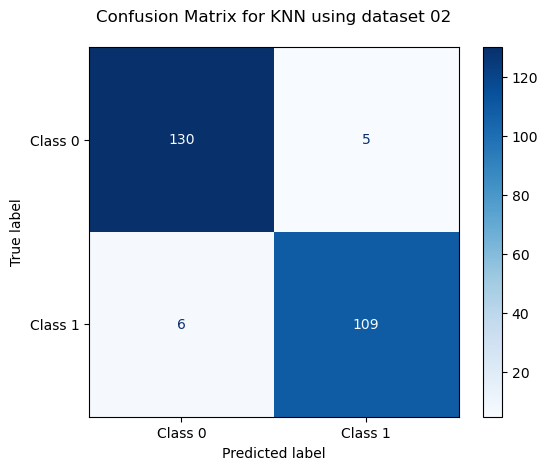

In [8]:
X_train, X_test, y_train, y_test = train_test_split(x2, y2)
y_pred, best_k = KNNcv(X_train, X_test, y_train)

acc = np.mean(y_pred == y_test)

print(f"Best k: {best_k}\n")
print(f"Accuracy: {acc}\n")
    
print(f"Classification report\n")
print(classification_report(y_test, y_pred))

# plot confusion matrix
plotConfusionMatrix("KNN using dataset 02\n", y_test, y_pred)

#### Case 3: Using Dataset 03

Best k: 3

Accuracy: 0.92

Classification report

              precision    recall  f1-score   support

           1       0.97      0.88      0.92        67
           2       0.88      0.97      0.92        58

    accuracy                           0.92       125
   macro avg       0.92      0.92      0.92       125
weighted avg       0.92      0.92      0.92       125



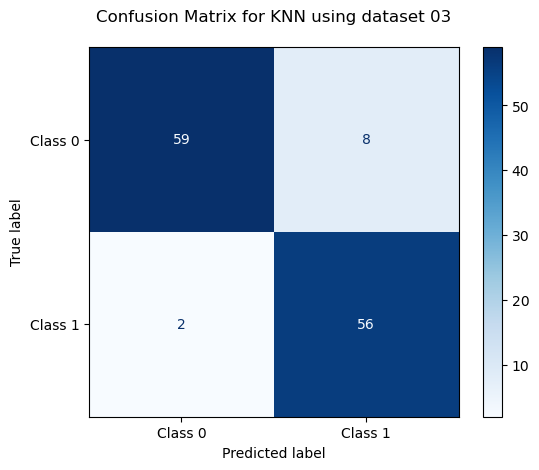

In [9]:
X_train, X_test, y_train, y_test = train_test_split(x3, y3)
y_pred, best_k = KNNcv(X_train, X_test, y_train)
acc = np.mean(y_pred == y_test)

print(f"Best k: {best_k}\n")

print(f"Accuracy: {acc}\n")
    
print(f"Classification report\n")
print(classification_report(y_test, y_pred))

# plot confusion matrix
plotConfusionMatrix("KNN using dataset 03\n", y_test, y_pred)

#### Case 4: Using Dataset 04

Best k: 2

Accuracy: 0.784

Classification report

              precision    recall  f1-score   support

           A       0.79      0.98      0.87        95
           B       0.71      0.17      0.27        30

    accuracy                           0.78       125
   macro avg       0.75      0.57      0.57       125
weighted avg       0.77      0.78      0.73       125



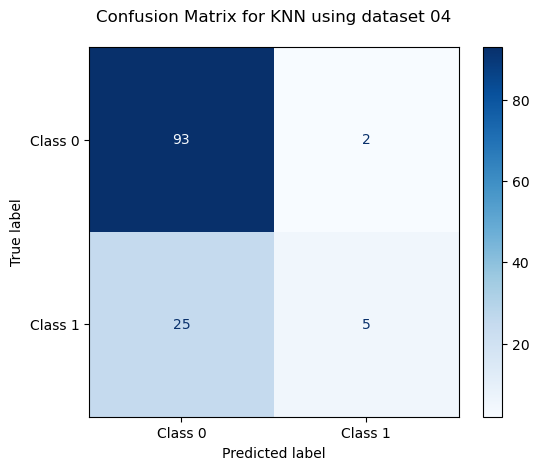

In [10]:
X_train, X_test, y_train, y_test = train_test_split(x4, y4)
y_pred, best_k = KNNcv(X_train, X_test, y_train)

acc = np.mean(y_pred == y_test)

print(f"Best k: {best_k}\n")
print(f"Accuracy: {acc}\n")
    
print(f"Classification report\n")
print(classification_report(y_test, y_pred))

# plot confusion matrix
plotConfusionMatrix("KNN using dataset 04\n", y_test, y_pred)

# Q2 

In [11]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import cross_val_score

# function to find the best alpha for pruning the tree
def TreeCV(X_train, y_train):
    base_model = DecisionTreeClassifier() # create a tree object
    path = base_model.cost_complexity_pruning_path(X_train, y_train) # fit the model with the training data
    
    scores = []
    # fit each alpha and perform 5-fold cross-validation
    for alpha in path.ccp_alphas:
        model = DecisionTreeClassifier(ccp_alpha=alpha)
        # perform cross validation
        score = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy').mean() # store the mean CV score
        scores.append(score)
    
    best_alpha = path.ccp_alphas[np.argmax(scores)] # get the best alpha
    
    return best_alpha

In [12]:
def LDA(X_train, X_test, y_train, y_test):
    ida = LinearDiscriminantAnalysis() # create a LDA object
    ida.fit(X_train, y_train) # fit the model with training data
    y_pred = ida.predict(X_test) # perform prediction using test data    
    acc = np.mean(y_pred == y_test) # calculate accuracy
    print(f"Accuracy: {acc}\n")
    
    print(f"Classification report")
    print(classification_report(y_test, y_pred)) # generate classification report
    plotConfusionMatrix("Linear Discriminant Analysis\n", y_test, y_pred) # plot confusion matrix
    
    return acc

def KNN(X_train, X_test, y_train, y_test):
    _, optimal_k = KNNcv(X_train, X_test, y_train) # get the best k
    knn = KNeighborsClassifier(n_neighbors=optimal_k) # set the model with best k
    knn.fit(X_train, y_train) # fit the training data
    y_pred = knn.predict(X_test) # perform prediction on test data
    acc = np.mean(y_pred == y_test) # calculate acc
    
    print(f"Accuracy: {acc}\n")
    
    print(f"Classification report")
    print(classification_report(y_test, y_pred)) # generate classification report
    
    plotConfusionMatrix("K-Nearest Neighbors (KNN) \n", y_test, y_pred) # plot confusion matrix
    
    return acc
    
def tree(X_train, X_test, y_train, y_test):
    best_alpha = TreeCV(X_train, y_train)
    tree = DecisionTreeClassifier(ccp_alpha=best_alpha)
    tree.fit(X_train, y_train)
    y_pred = tree.predict(X_test)
    acc = np.mean(y_pred == y_test)

    print(f"Accuracy: {acc}\n")
    print(f"Classification report")
    print(classification_report(y_test, y_pred))

    plotConfusionMatrix("Decision Tree Classifier \n", y_test, y_pred)
    return acc

### Linear Discriminant Analysis

#### Case 1: Using Dataset 01

Accuracy: 0.832

Classification report
              precision    recall  f1-score   support

           A       0.80      0.84      0.82        57
           B       0.86      0.82      0.84        68

    accuracy                           0.83       125
   macro avg       0.83      0.83      0.83       125
weighted avg       0.83      0.83      0.83       125



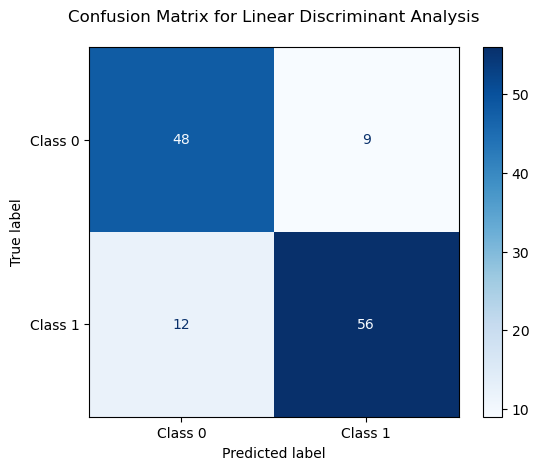

In [13]:
X_train, X_test, y_train, y_test = train_test_split(x1.reshape(-1,1), y1)
lda_d1_acc = LDA(X_train, X_test, y_train, y_test)

#### Case 2: Using Dataset 02

Accuracy: 0.968

Classification report
              precision    recall  f1-score   support

           1       0.96      0.98      0.97       122
           2       0.98      0.96      0.97       128

    accuracy                           0.97       250
   macro avg       0.97      0.97      0.97       250
weighted avg       0.97      0.97      0.97       250



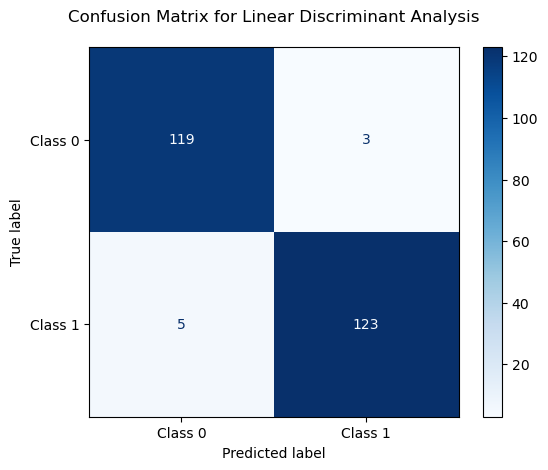

In [14]:
X_train, X_test, y_train, y_test = train_test_split(x2, y2)
lda_d2_acc = LDA(X_train, X_test, y_train, y_test)

#### Case 3: Using Dataset 03

Accuracy: 0.928

Classification report
              precision    recall  f1-score   support

           1       0.97      0.90      0.93        67
           2       0.89      0.97      0.93        58

    accuracy                           0.93       125
   macro avg       0.93      0.93      0.93       125
weighted avg       0.93      0.93      0.93       125



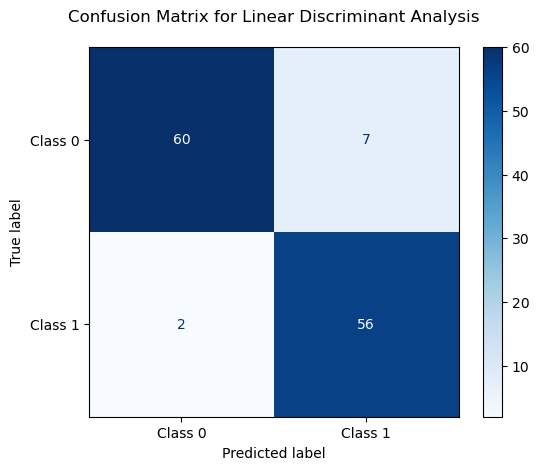

In [15]:
X_train, X_test, y_train, y_test = train_test_split(x3, y3)
lda_d3_acc = LDA(X_train, X_test, y_train, y_test)

#### Case 4: Using Dataset 04

Accuracy: 0.816

Classification report
              precision    recall  f1-score   support

           A       0.88      0.89      0.89       102
           B       0.50      0.48      0.49        23

    accuracy                           0.82       125
   macro avg       0.69      0.69      0.69       125
weighted avg       0.81      0.82      0.81       125



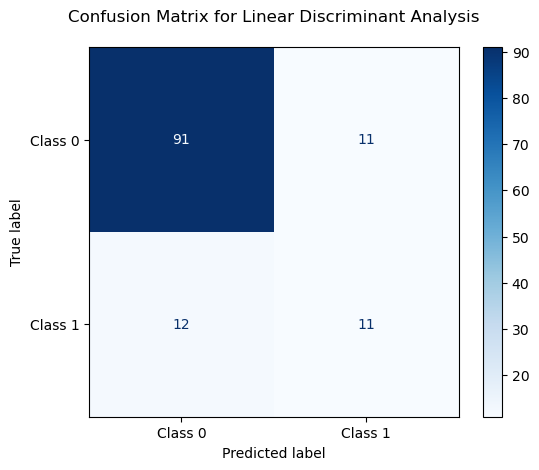

In [16]:
X_train, X_test, y_train, y_test = train_test_split(x4, y4)
lda_d4_acc = LDA(X_train, X_test, y_train, y_test)

### K-Nearest Neighbors (KNN) 

#### Case 1: Using Dataset 01

Accuracy: 0.824

Classification report
              precision    recall  f1-score   support

           A       0.78      0.83      0.80        54
           B       0.87      0.82      0.84        71

    accuracy                           0.82       125
   macro avg       0.82      0.83      0.82       125
weighted avg       0.83      0.82      0.82       125



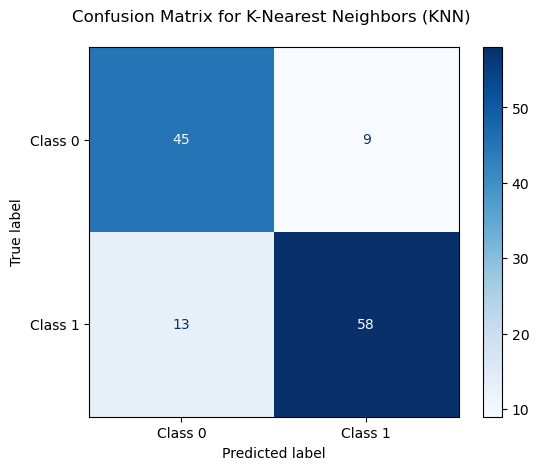

In [17]:
X_train, X_test, y_train, y_test = train_test_split(x1.reshape(-1,1), y1)
knn_d1_acc = KNN(X_train, X_test, y_train, y_test)

#### Case 2: Using Dataset 02

Accuracy: 0.96

Classification report
              precision    recall  f1-score   support

           1       0.94      0.98      0.96       123
           2       0.98      0.94      0.96       127

    accuracy                           0.96       250
   macro avg       0.96      0.96      0.96       250
weighted avg       0.96      0.96      0.96       250



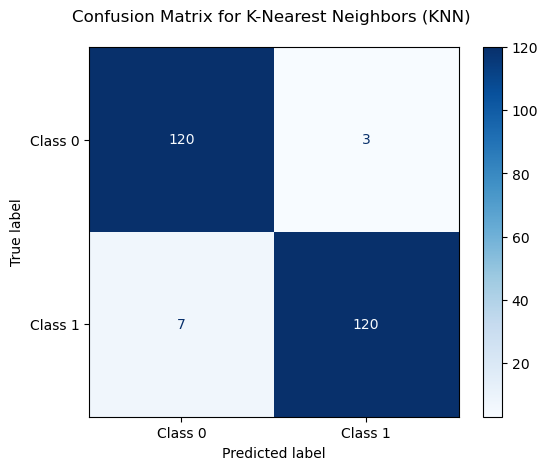

In [18]:
X_train, X_test, y_train, y_test = train_test_split(x2, y2)
knn_d2_acc = KNN(X_train, X_test, y_train, y_test)

#### Case 3: Using Dataset 03

Accuracy: 0.936

Classification report
              precision    recall  f1-score   support

           1       0.92      0.95      0.94        62
           2       0.95      0.92      0.94        63

    accuracy                           0.94       125
   macro avg       0.94      0.94      0.94       125
weighted avg       0.94      0.94      0.94       125



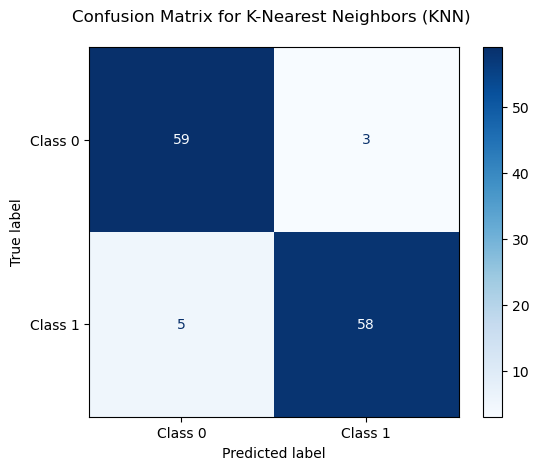

In [19]:
X_train, X_test, y_train, y_test = train_test_split(x3, y3)
knn_d3_acc = KNN(X_train, X_test, y_train, y_test)

#### Case 4: Using Dataset 04

Accuracy: 0.816

Classification report
              precision    recall  f1-score   support

           A       0.82      0.97      0.89        97
           B       0.73      0.29      0.41        28

    accuracy                           0.82       125
   macro avg       0.78      0.63      0.65       125
weighted avg       0.80      0.82      0.78       125



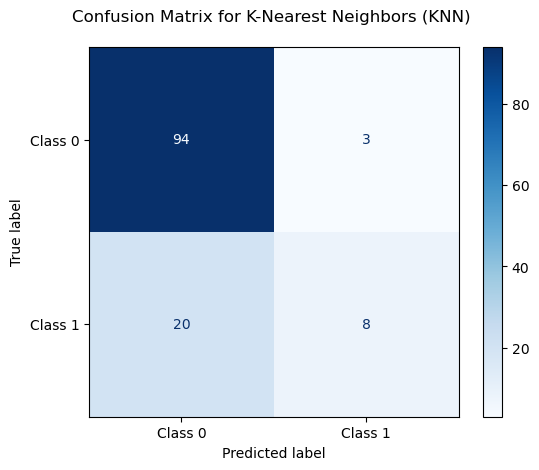

In [20]:
X_train, X_test, y_train, y_test = train_test_split(x4, y4)
knn_d4_acc = KNN(X_train, X_test, y_train, y_test)

### Decision Tree Classifier 

#### Case 1: Using Dataset 01

Accuracy: 0.84

Classification report
              precision    recall  f1-score   support

           A       0.80      0.88      0.84        60
           B       0.88      0.80      0.84        65

    accuracy                           0.84       125
   macro avg       0.84      0.84      0.84       125
weighted avg       0.84      0.84      0.84       125



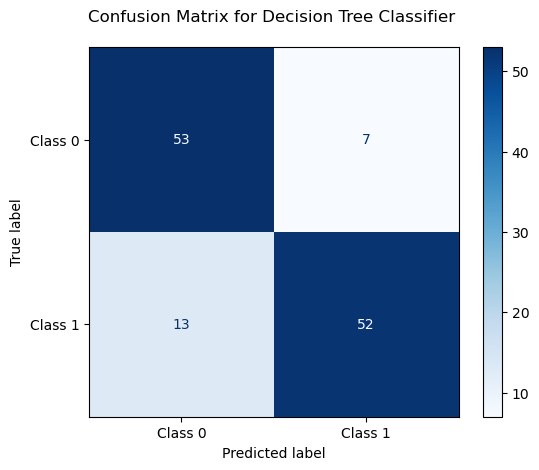

In [21]:
X_train, X_test, y_train, y_test = train_test_split(x1.reshape(-1,1), y1)
tree_d1_acc = tree(X_train, X_test, y_train, y_test)

#### Case 2: Using Dataset 02

Accuracy: 0.956

Classification report
              precision    recall  f1-score   support

           1       0.94      0.97      0.95       119
           2       0.98      0.94      0.96       131

    accuracy                           0.96       250
   macro avg       0.96      0.96      0.96       250
weighted avg       0.96      0.96      0.96       250



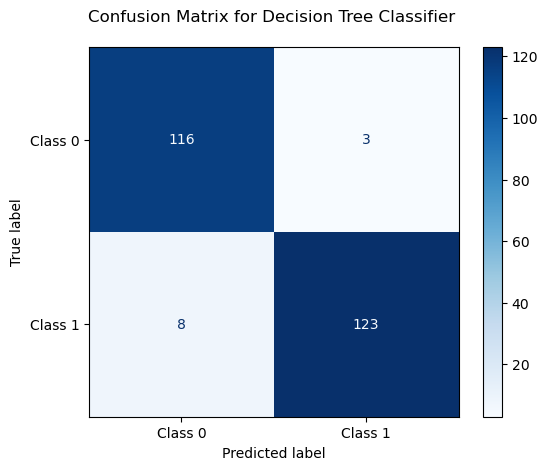

In [22]:
X_train, X_test, y_train, y_test = train_test_split(x2, y2)
tree_d2_acc = tree(X_train, X_test, y_train, y_test)

#### Case 3: Using Dataset 03

Accuracy: 0.968

Classification report
              precision    recall  f1-score   support

           1       1.00      0.94      0.97        72
           2       0.93      1.00      0.96        53

    accuracy                           0.97       125
   macro avg       0.96      0.97      0.97       125
weighted avg       0.97      0.97      0.97       125



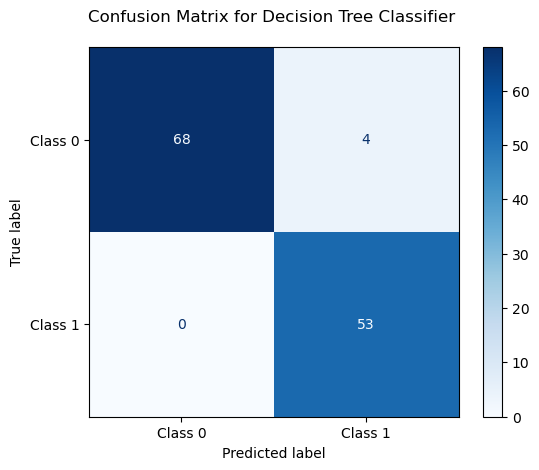

In [23]:
X_train, X_test, y_train, y_test = train_test_split(x3, y3)
tree_d3_acc = tree(X_train, X_test, y_train, y_test)

#### Case 4: Using Dataset 04

Accuracy: 0.824

Classification report
              precision    recall  f1-score   support

           A       0.85      0.95      0.90       101
           B       0.58      0.29      0.39        24

    accuracy                           0.82       125
   macro avg       0.72      0.62      0.64       125
weighted avg       0.80      0.82      0.80       125



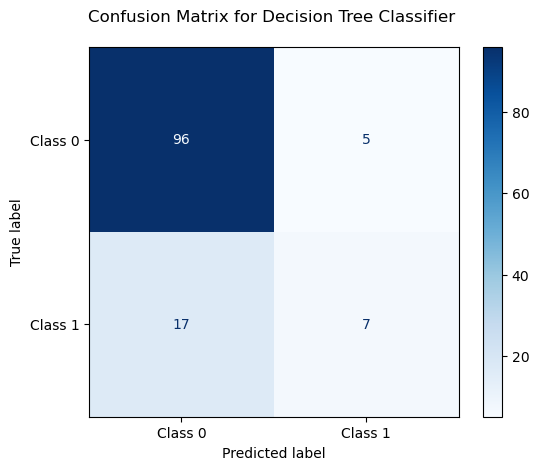

In [24]:
X_train, X_test, y_train, y_test = train_test_split(x4, y4)
tree_d4_acc = tree(X_train, X_test, y_train, y_test)

### Comparison

In [25]:
import pandas as pd

pd.DataFrame({
    "Dataset": ["D1", "D2", "D3", "D4"],
    "LDA": [lda_d1_acc, lda_d2_acc, lda_d3_acc, lda_d4_acc],
    "KNN": [knn_d1_acc, knn_d2_acc, knn_d3_acc, knn_d4_acc],
    "Tree": [tree_d1_acc, tree_d2_acc, tree_d3_acc, tree_d4_acc]
})

,Dataset,LDA,KNN,Tree
0,D1,0.832,0.824,0.840
1,D2,0.968,0.960,0.956
2,D3,0.928,0.936,0.968
3,D4,0.816,0.816,0.824
